CalvalXY is the calibation/validation method used, made specifically for this paper. 

This notebook aims to explain step by step the process used to split the data. 

# 0. Initialize data

First, we need some data to illustate how the algorithm works. Simulated data will be used, see 'notebooks/simulate.ipynb' to know more.

In [24]:
from dual_spls.simulate import simulate
## Configuration:
# Simulation configuration:
coefs = [0, 1, 0, 1, 1, 0, 0, 1, 1] 
n = 300
p = [1000]
nondes = [30]
sigmaondes = [0.40]
sigma_y = 0.05

# Split configuration:
split_mode = "random"

# Dual-sPLS configuration
norm = "pseudo-lasso"

simulation_results = simulate(n=n, p=p, nondes=nondes , sigmaondes=sigmaondes, sigma_y=sigma_y, coefs=coefs)
X, y = simulation_results["X"], simulation_results["y"]

# 1. Prepare data

The calvalxy function takes the data as an entry and offers different options to prepare the data specificaly for the purpose of splitting it.

In [25]:
from sklearn.decomposition import PCA

# center data (arg "center : True")
X_proc = (X - X.mean(axis=0)).copy()
n_samples = X_proc.shape[0]

# dimensionality reduction methods (arg: "method = "euclidian"/"pca_euclidian"/"svd_euclidian"")
method = "svd_euclidian"
pc = 3 # number of principal components to use in case of a pca
if method == "pca_euclidian" or method == "svd_euclidian":
    pca = PCA(n_components=pc)
    scores = pca.fit_transform(X_proc) # shape (n_samples, pc)

    if method == "pca_euclidian":
        X_proj = scores

    elif method == "svd_euclidian":
        """
        SVD: X = U @ Sigma @ V^T

        PCA: T = X @ V 

        ==> T = (U @ Sigma @ V^T) @ V

        V is orthogonal => V^TV = I

        ==> T = U @ Sigma

        ==> U = T @ Sigma^{-1}

        Allows to get the scores as if SVD was used instead of PCA
        """
        singular_values = pca.singular_values_
        X_proj = scores / singular_values 

# X_proj contains the result of PCA or SVD applied on the eventually centered X matrix 

# 2. Splitting algorithm

The splitting process relies on a sequence of steps:

### 2.1. Assign a group to each sample

In [26]:
from dual_spls.get_bin_indices import get_bin_indices
from dual_spls.split import split

# Firstly, the samples are assigned to a subgroup of samples using the get_bin_indices function
# This function divides the response vector y in n_cells cells of equal range and attributes an
# index to the observations according to the corresponding cell.
n_bins = 10
bin_indices = get_bin_indices(y, n_bins=n_bins)

print("bin_indices: ", bin_indices)

bin_indices:  [5 6 5 7 6 5 6 6 8 4 6 4 7 6 8 5 4 5 6 6 4 0 5 7 6 3 3 8 5 4 7 6 5 8 7 6 5
 4 6 6 6 6 7 4 6 5 7 6 6 6 7 6 5 2 6 4 5 5 7 8 7 3 5 4 3 8 7 2 5 4 5 4 5 7
 6 5 7 4 5 3 4 8 6 2 2 6 3 7 6 6 4 7 5 5 4 3 7 6 3 5 4 3 6 7 6 2 5 4 7 3 6
 6 7 6 3 9 6 6 5 6 9 6 6 6 4 4 8 6 4 6 8 5 6 5 4 4 4 5 8 8 4 4 6 7 5 4 6 7
 4 8 3 6 7 4 3 6 6 4 6 4 5 7 8 5 3 6 5 4 7 5 6 2 6 2 5 6 7 4 6 6 7 5 3 0 7
 4 6 3 6 6 9 6 5 5 7 7 4 5 8 2 5 2 5 6 5 7 3 3 6 2 4 7 3 5 7 6 6 5 7 7 5 4
 4 6 8 4 3 3 3 5 5 4 6 6 8 3 3 6 7 5 7 5 7 4 4 5 5 6 5 5 6 3 7 4 2 7 7 6 6
 5 2 5 4 6 5 6 4 4 3 6 5 4 3 7 2 4 5 5 6 4 5 5 4 4 6 6 4 4 4 4 4 7 5 6 7 2
 2 6 7 7]


More precisely, this group attribution takes the minimum and the maximum values in y, and split the range of values in n_bins ranges of same length.

That means that:
- It is not made to make balanced groups;
- If there is an anomaly in the values of y, this method accepts to have a group with only 1 sample, and possibly 0 in some other groups. 

We can illustrate that by an example:

y values:  [1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Attributed group by the function:  [0 4 5 5 6 6 7 7 8 8 9 9]
Histogram showing how many samples are attributed to each of the 10 group:


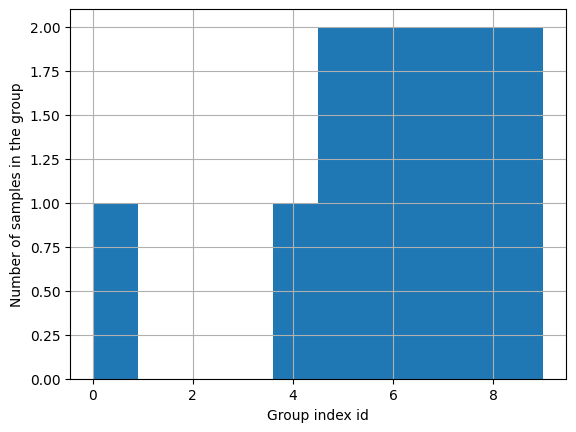

In [27]:
import numpy as np
import matplotlib.pyplot as plt

y_illustration = [1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
bin_indices_illustration = get_bin_indices(y_illustration, n_bins=n_bins)

print("y values: ", y_illustration)
print("Attributed group by the function: ", bin_indices_illustration)
print("="*100)

print(f"Histogram showing how many samples are attributed to each of the {n_bins} group:")
plt.hist(bin_indices_illustration, bins=10)
plt.xlabel("Group index id")
plt.ylabel("Number of samples in the group")
plt.grid()
plt.show()


### 2.2. Decide how many samples to take from each group

Then, the next step is to decide how many sample to take in each group for calibration. This step involves the get_callist (get calibration list) function. 

This funciton takes a pcal argument, which corresponds to what percentage of samples to take out of all the samples at hand. It takes one sample in each group sequentially until enough samples are taken. If a group is empty, the process keeps going by taking samples in other groups. 

What that means is that:

- Unlike a random or balanced sampling method, it is not trying to keep samples in each group for validation but will accept to empty completely a group for calibration purpose if it allows the algorithme to have a more balanced dataset for calibration;
- Validation may be done on only a small portion of groups in case of a very unbalanced group splitting made in the previous step

In [28]:
from dual_spls.callist import get_calList

pcal = 90 # Let's take 90% of the available samples for calibration
calList = get_calList(bin_indices, pcal, n_bins=n_bins).astype(int)

print(f"calList contains {n_bins} values, corresponding to the number of samples to take in each group for calibration")
print("calList: ", calList)

calList contains 10 values, corresponding to the number of samples to take in each group for calibration
calList:  [ 2  0 15 27 54 54 54 45 16  3]


For many groups, the number of samples chosen for calibration corresponds to the total number of available samples in the group: 


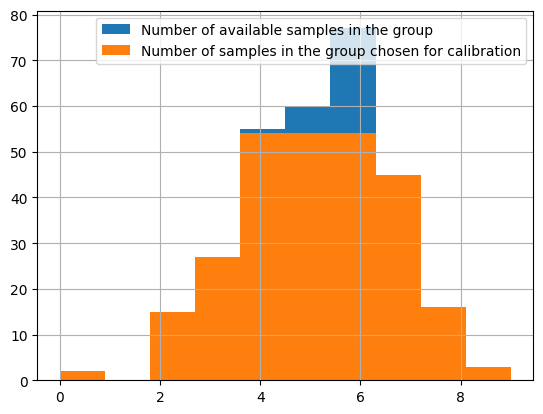

In [29]:
calList_repeat = []
for bin_index in range(n_bins):
    for k in range(calList[bin_index]):
        calList_repeat.append(bin_index)

print("For many groups, the number of samples chosen for calibration corresponds to the total number of available samples in the group: ")
plt.hist(bin_indices, bins=10, label="Number of available samples in the group")
plt.hist(calList_repeat, bins=10, label="Number of samples in the group chosen for calibration")
plt.legend()
plt.grid()

The latter experiment can also be done on our illustration labels $y$:

For many groups, the number of samples chosen for calibration corresponds to the total number of available samples in the group: 


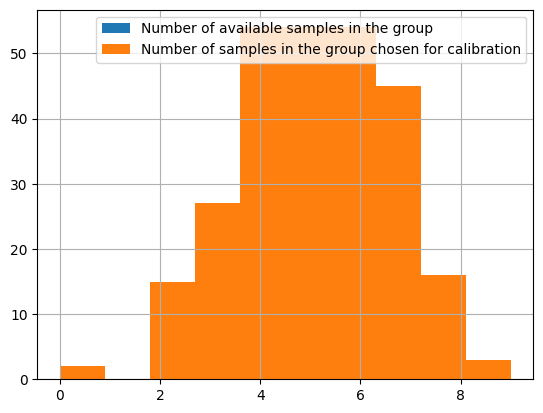

In [ ]:
pcal = 90 # Let's take 90% of the available samples for calibration
calList_illustration = get_calList(bin_indices_illustration, pcal, n_bins=n_bins).astype(int)

calList_repeat_illustration = []
for bin_index in range(n_bins):
    for k in range(calList_illustration[bin_index]):
        calList_repeat_illustration.append(bin_index)

print("For many groups, the number of samples chosen for calibration corresponds to the total number of available samples in the group: ")
plt.hist(bin_indices_illustration, bins=10, label="Number of available samples in the group")
plt.hist(calList_repeat_illustration, bins=10, label="Number of samples in the group chosen for calibration")
plt.legend()
plt.grid()